### Importation des modules

In [2]:
import os
os.chdir("../.")

In [31]:
os.getcwd()

'/Users/epiphaneegah/Documents/jan26_cde_crypto'

In [32]:
from pathlib import Path
import sys
import glob
import pandas as pd 
from matplotlib import pyplot as plt # noqa: E402
import re
from models import (modelisation_engel_granger, modelisation_arch,
                    modelisation_xgb, plot_acf_pacf,
                    dickey_fuller_augmente, dickey_fuller_simple,
                    phillips_perron, modelisation_rf)

In [28]:
import importlib
import models
importlib.reload(models)

<module 'models' from '/Users/epiphaneegah/Documents/jan26_cde_crypto/models.py'>

### SARIMA

##### Exemple sur le Bitcoin 1 h

In [5]:
data = pd.read_json("data/BTCUSDT_1h.json")
series = data["close"]

# Exécution des trois tests

dickey_fuller_simple(series) 
dickey_fuller_augmente(series) 
phillips_perron(series)

=== Dickey-Fuller simple ===
Statistique de test : -1.2881
P-value             : 0.6346
Valeurs critiques   : {'1%': np.float64(-3.4304341409141776), '5%': np.float64(-2.8615771888483623), '10%': np.float64(-2.566789794343126)}
=> Série non stationnaire (on ne rejette pas H0)

=== Dickey-Fuller augmenté (ADF) ===
Statistique de test : -1.2366
P-value             : 0.6576
Nb de lags utilisés : 64
Nb d'observations   : 77657
Valeurs critiques   : {'1%': np.float64(-3.430434210260103), '5%': np.float64(-2.861577219497643), '10%': np.float64(-2.566789810656758)}
=> Série non stationnaire (on ne rejette pas H0)

=== Phillips-Perron ===
Statistique de test : -1.2310
P-value             : 0.6601
Valeurs critiques   : {'1%': np.float64(-3.4304341409141776), '5%': np.float64(-2.8615771888483623), '10%': np.float64(-2.566789794343126)}
=> Série non stationnaire (on ne rejette pas H0)



Test Statistic,-1.231
P-value,0.660
Lags,64


In [6]:
series = series.diff().dropna()

In [7]:
dickey_fuller_simple(series)
dickey_fuller_augmente(series)
phillips_perron(series)

=== Dickey-Fuller simple ===
Statistique de test : -281.8890
P-value             : 0.0000
Valeurs critiques   : {'1%': np.float64(-3.4304341419968294), '5%': np.float64(-2.861577189326869), '10%': np.float64(-2.56678979459782)}
=> Série stationnaire (on rejette H0)

=== Dickey-Fuller augmenté (ADF) ===
Statistique de test : -34.7031
P-value             : 0.0000
Nb de lags utilisés : 63
Nb d'observations   : 77657
Valeurs critiques   : {'1%': np.float64(-3.430434210260103), '5%': np.float64(-2.861577219497643), '10%': np.float64(-2.566789810656758)}
=> Série stationnaire (on rejette H0)

=== Phillips-Perron ===
Statistique de test : -282.3023
P-value             : 0.0000
Valeurs critiques   : {'1%': np.float64(-3.4304341419968294), '5%': np.float64(-2.861577189326869), '10%': np.float64(-2.56678979459782)}
=> Série stationnaire (on rejette H0)



Test Statistic,-282.302
P-value,0.000
Lags,64


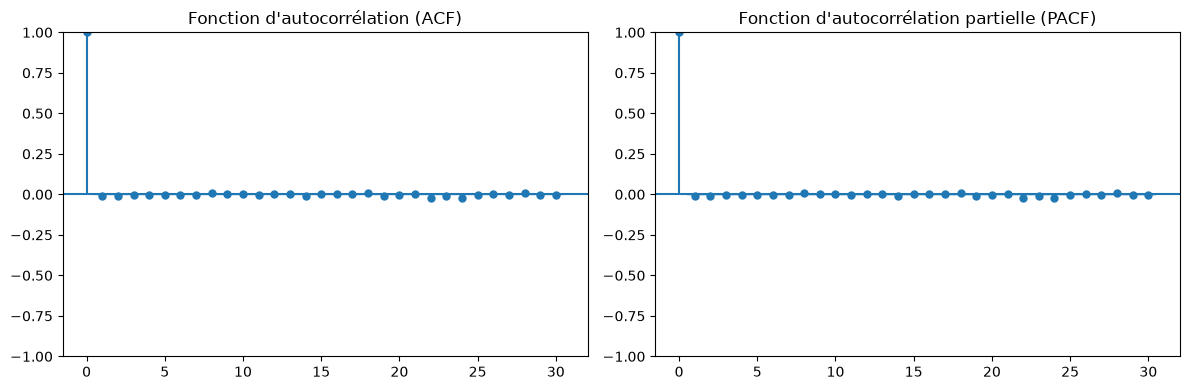

In [8]:
# choix ARIMA(p, q)
plot_acf_pacf(series)

### XGBoostRegressor

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="xgboost"
)

for path in glob.glob("data/*.json"):
    data = pd.read_json(path)
    regex = re.compile(r"(\w+)(?:(?=\.json))")
    crypto, interval = regex.findall(path)[0].split("_")
    print(f"{crypto} avec l'interval {interval}")
    modelisation_xgb(data=data, n_iter=200, crypto=crypto, interval=interval)
    print("------------------------------------------------------")

### Modèle à correction d'erreur (Angel et granger)

$$\Delta Y_t = \alpha + \beta_1 \Delta X_t - \lambda (Y_{t-1} - \gamma X_{t-1}) + \varepsilon_t$$

BTCUSDT avec l'interval 1d
P-value de  close :  0.6235025226706791
P-value de  close différencié :  1.3972641132695024e-18
P-value de moving_average :  0.3911525233195719
P-value de moving_average différencié :  0.0545247531190021
------------------------------------------------------
BTCUSDT avec l'interval 1h
RMSE score sur le train set :  217.33788990712986
RMSE score sur le test set :  429.9454916681868
Le RMSE score du test set 
                  est supérieur à celui du train set 
                  de 97.82353268079751 %


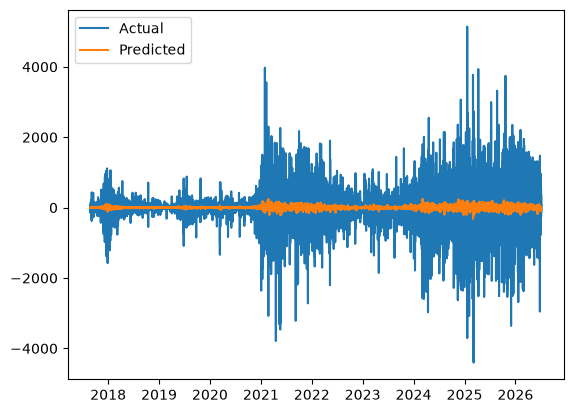

------------------------------------------------------
BNBUSDT avec l'interval 1d
RMSE score sur le train set :  12.781803266651211
RMSE score sur le test set :  22.315892746391615
Le RMSE score du test set 
                  est supérieur à celui du train set 
                  de 74.5911142648834 %


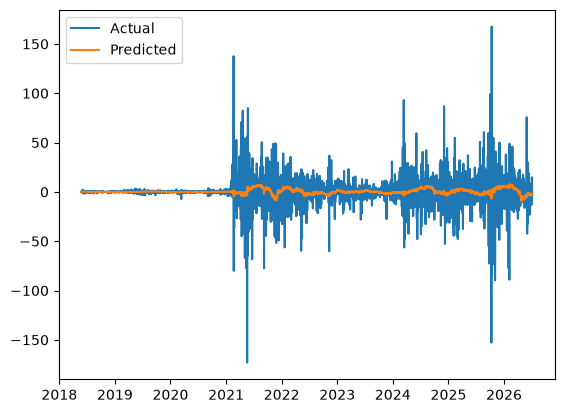

------------------------------------------------------
BNBUSDT avec l'interval 1h
RMSE score sur le train set :  2.474493335821991
RMSE score sur le test set :  4.478442102945731
Le RMSE score du test set 
                  est supérieur à celui du train set 
                  de 80.98420545788447 %


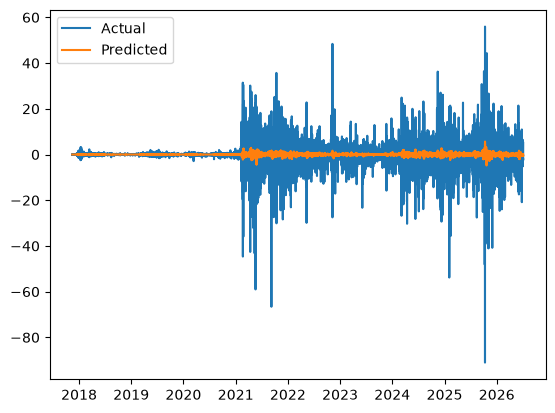

------------------------------------------------------
ETHUSDT avec l'interval 1d
RMSE score sur le train set :  77.78992060937989
RMSE score sur le test set :  111.4763799167901
Le RMSE score du test set 
                  est supérieur à celui du train set 
                  de 43.304401191724956 %


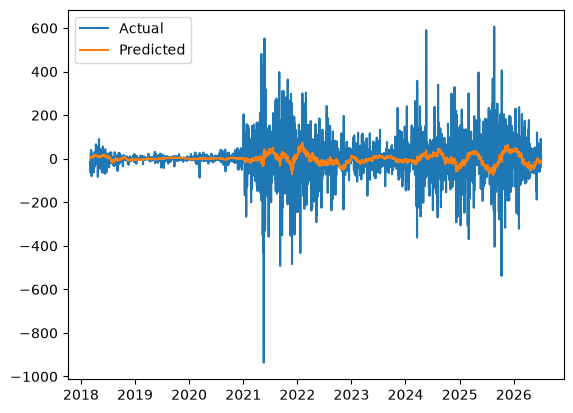

------------------------------------------------------
ETHUSDT avec l'interval 1h
RMSE score sur le train set :  15.685934272637867
RMSE score sur le test set :  20.79480887739799
Le RMSE score du test set 
                  est supérieur à celui du train set 
                  de 32.56978204780515 %


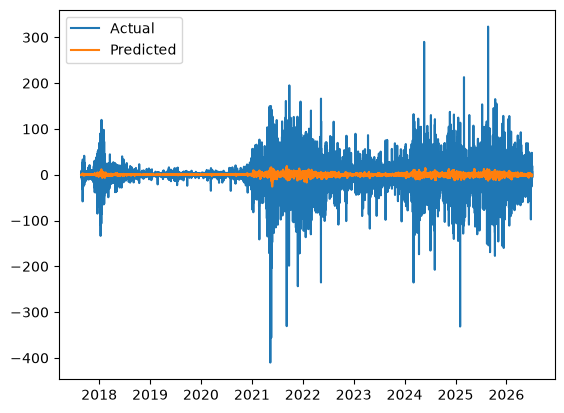

------------------------------------------------------


In [ ]:
for path in glob.glob("data/*.json"):
    regex = re.compile(r"(\w+)(?:(?=\.json))")
    crypto, interval = regex.findall(path)[0].split("_")
    print(f"{crypto} avec l'interval {interval}")
    data = pd.read_json(path)
    modelisation_engel_granger(data=data)
    print("------------------------------------------------------")

### ARCH

BTCUSDT avec l'interval 1d


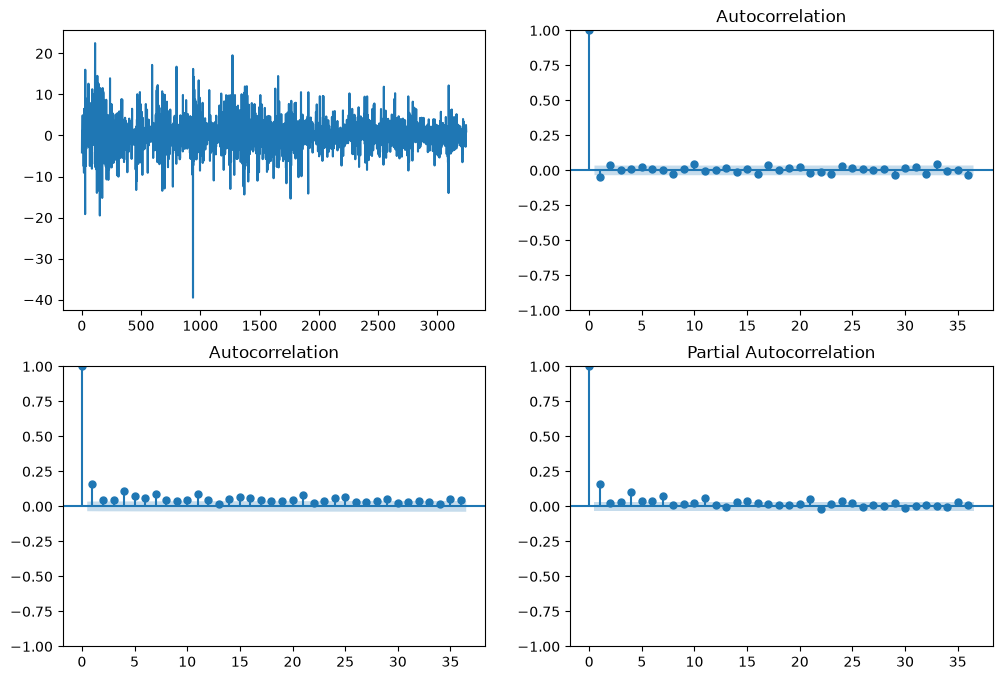

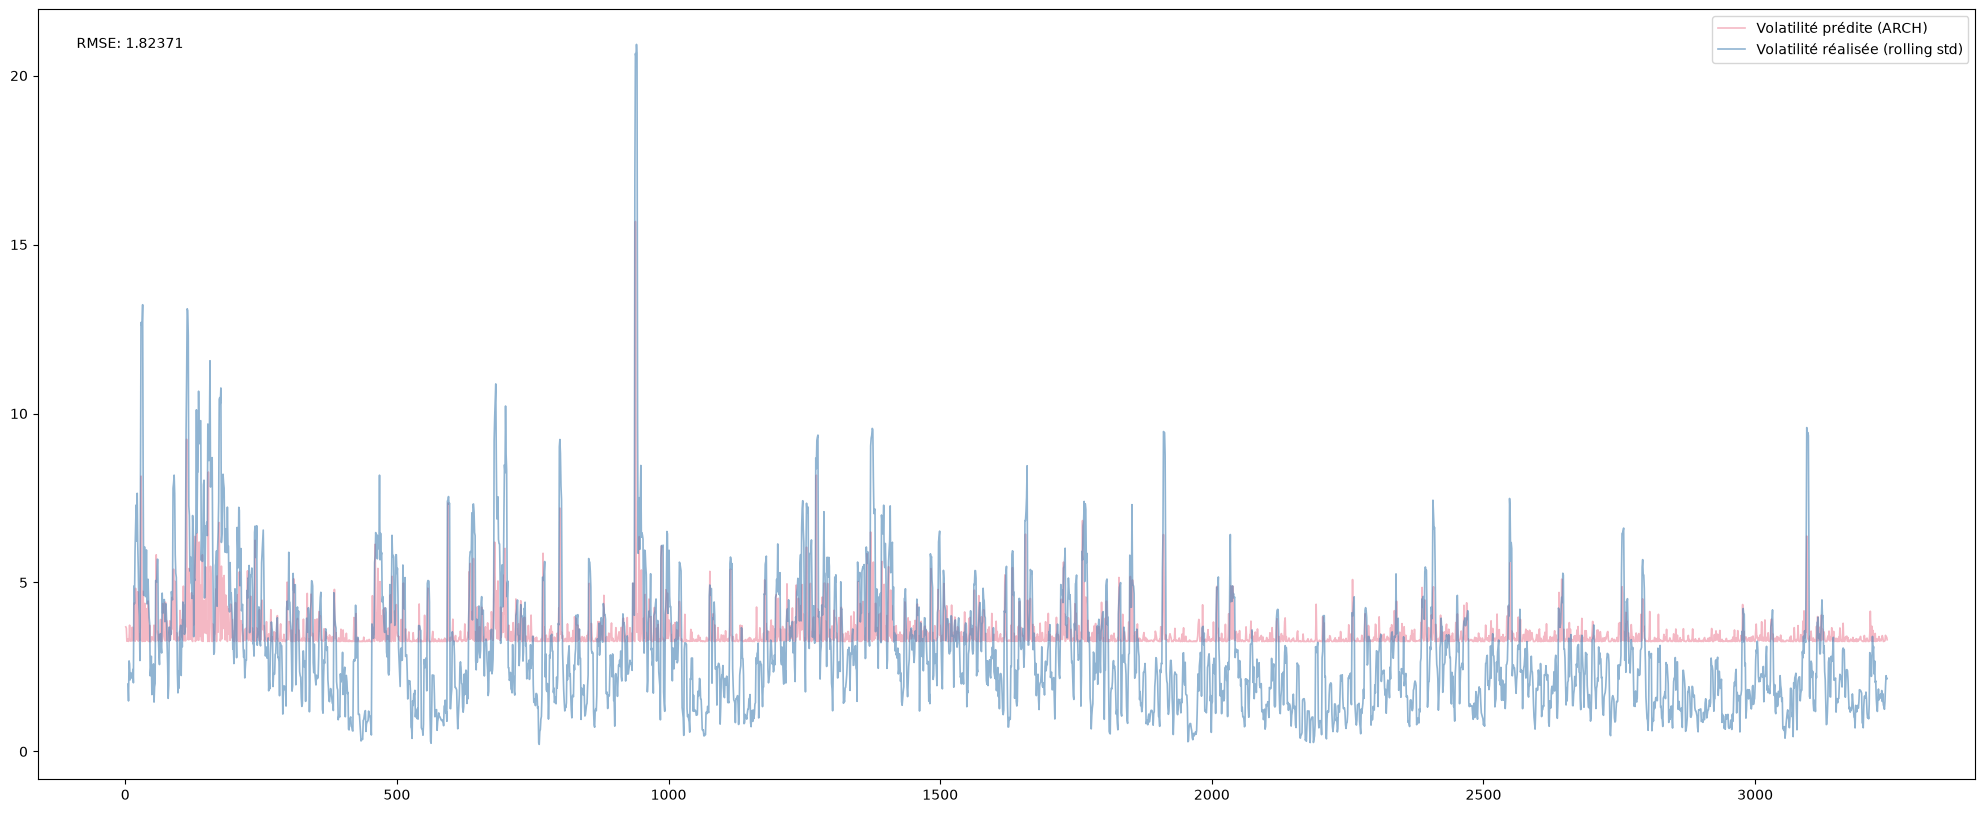

------------------------------------------------------
BTCUSDT avec l'interval 1h


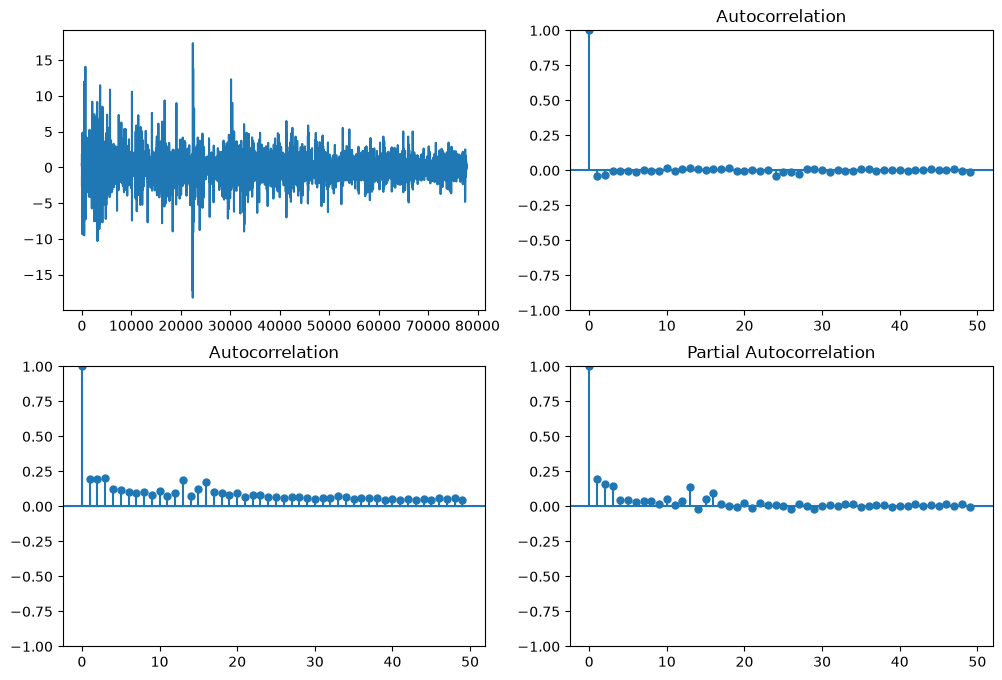

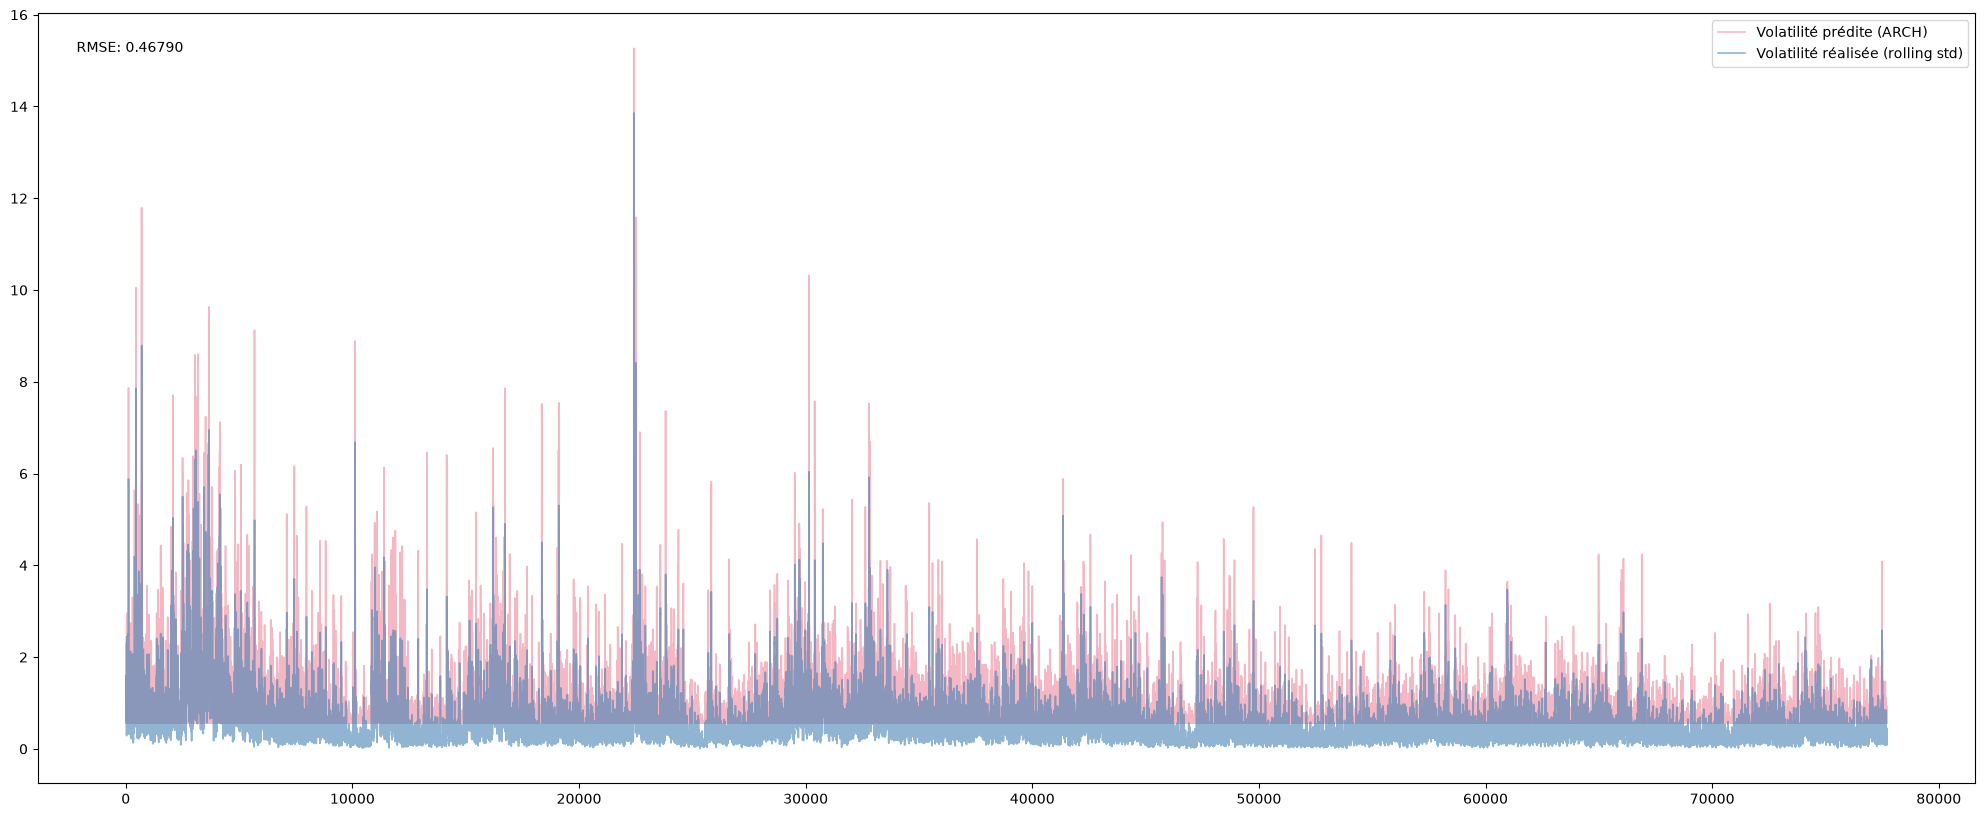

------------------------------------------------------
BNBUSDT avec l'interval 1d


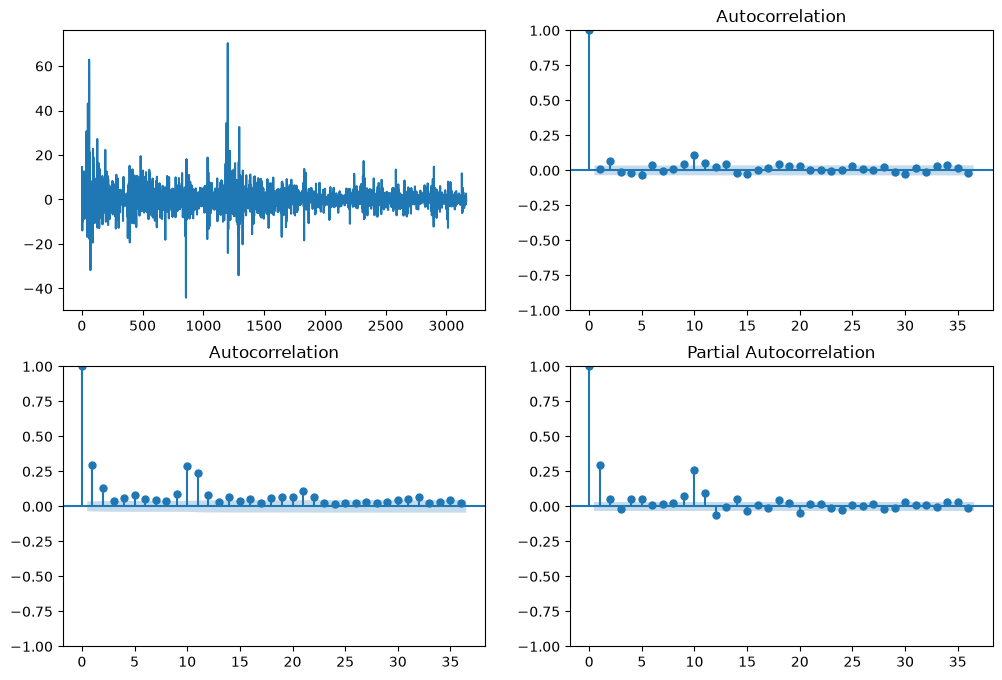

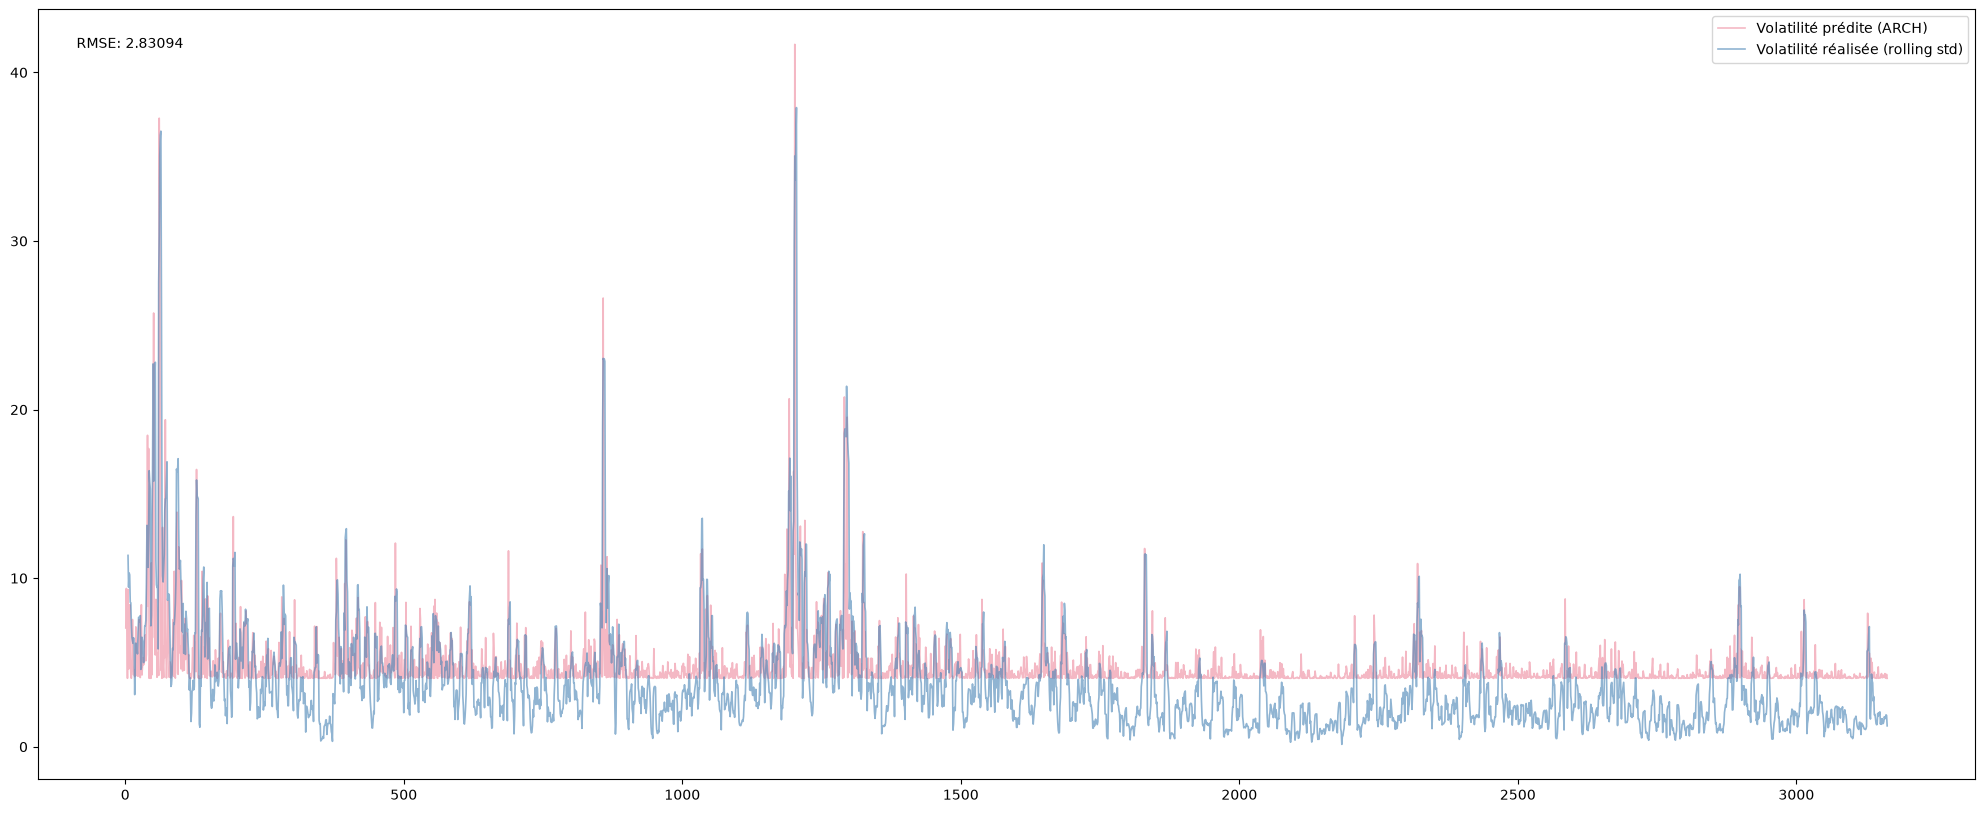

------------------------------------------------------
BNBUSDT avec l'interval 1h


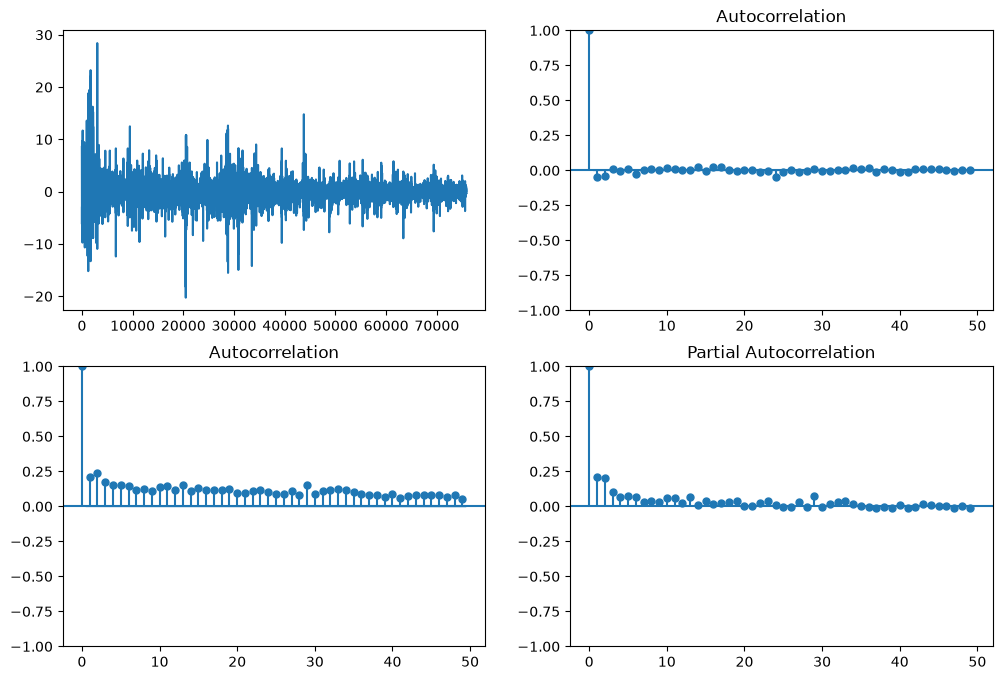

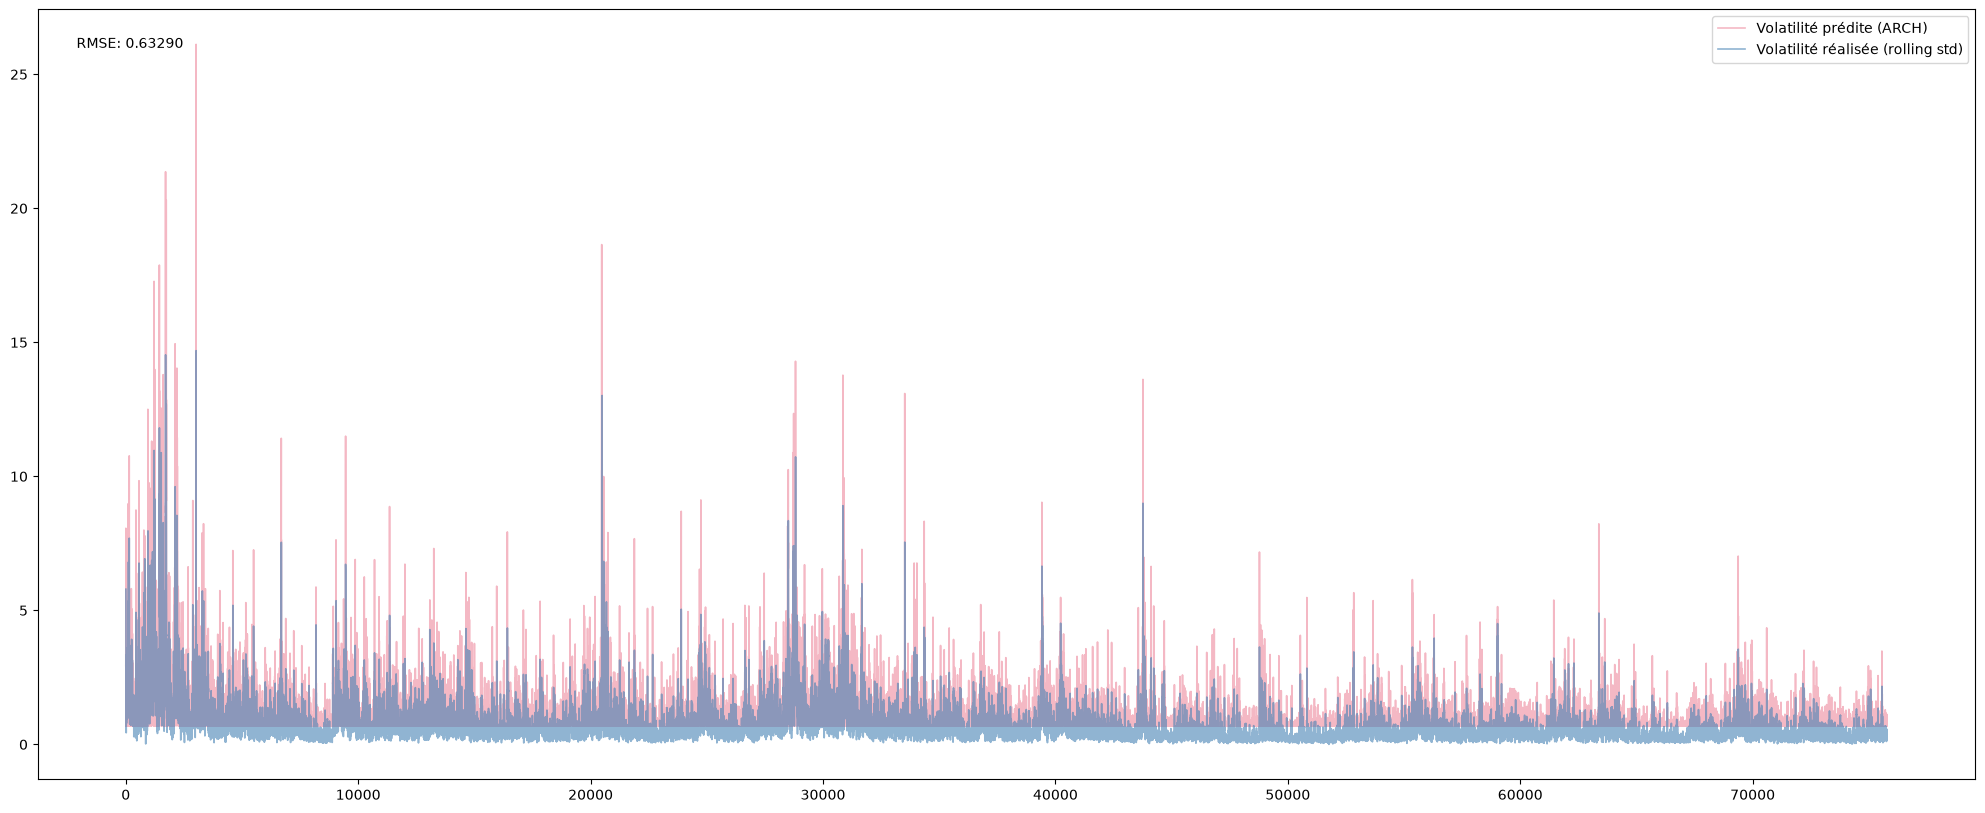

------------------------------------------------------
ETHUSDT avec l'interval 1d


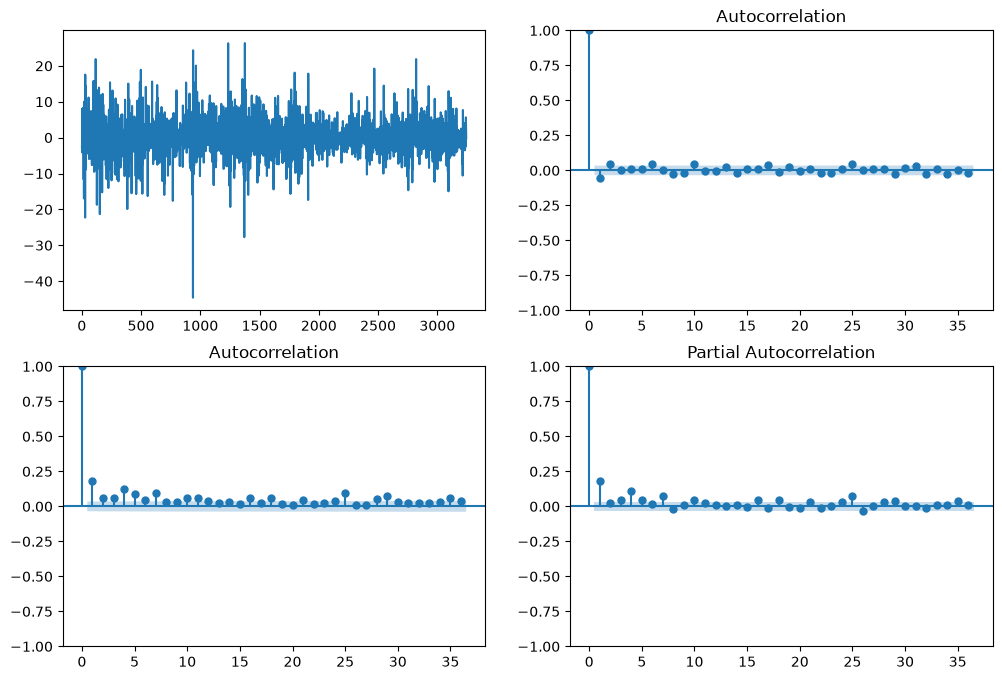

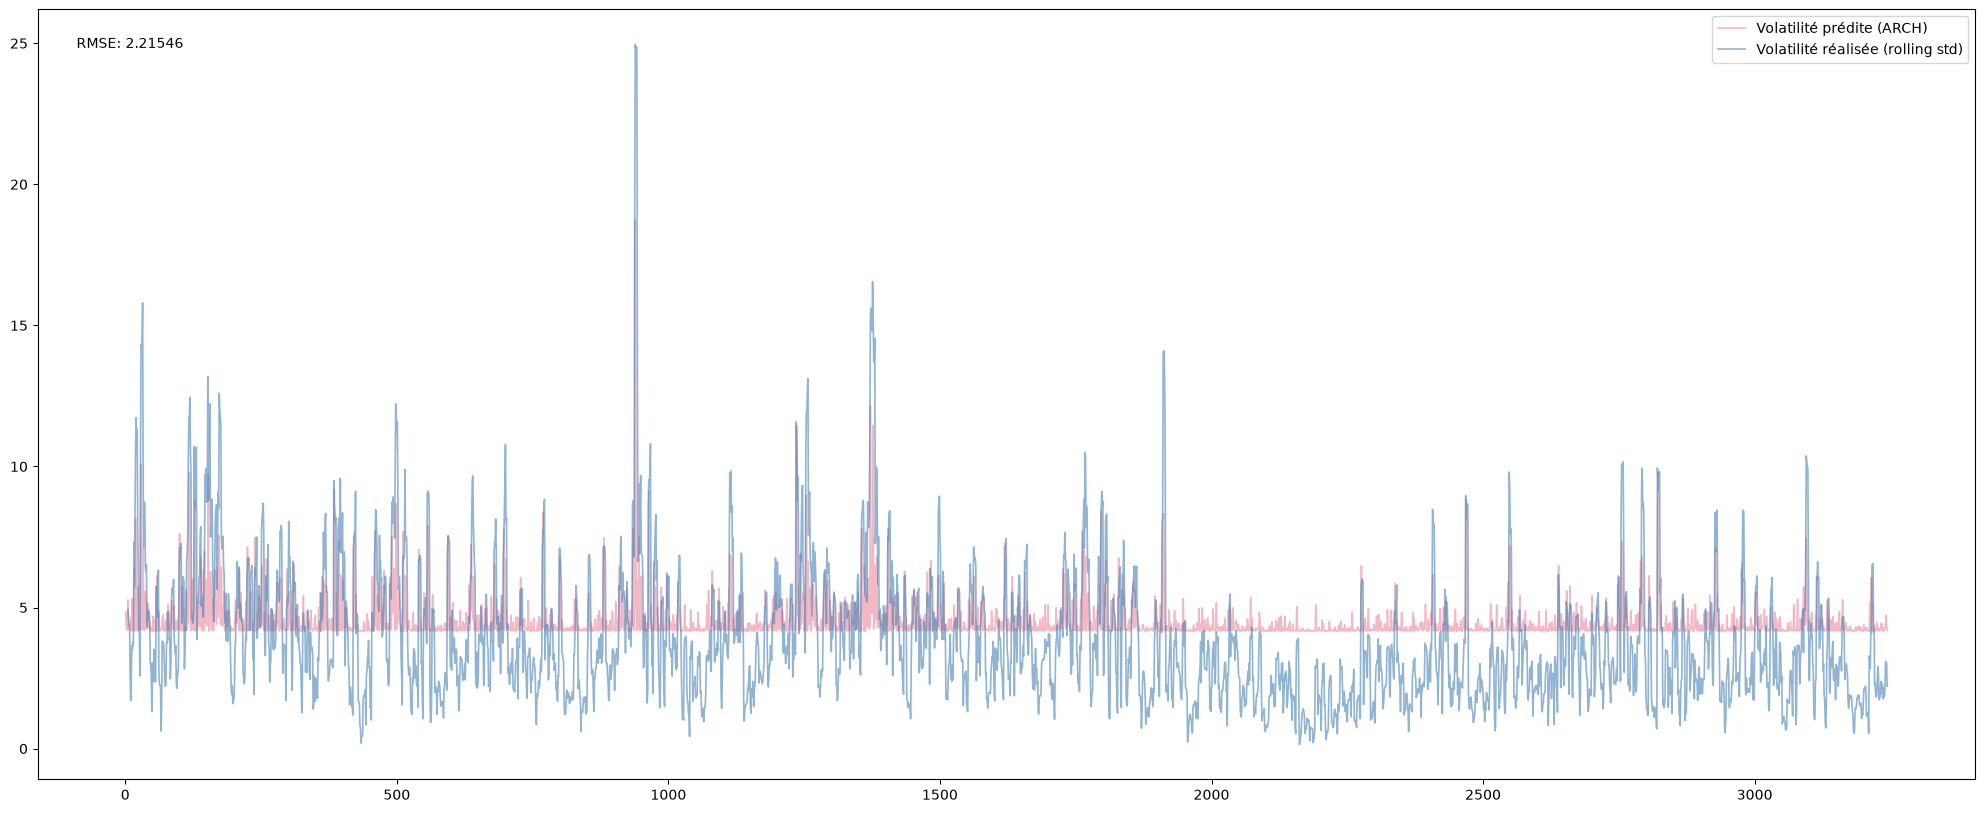

------------------------------------------------------
ETHUSDT avec l'interval 1h


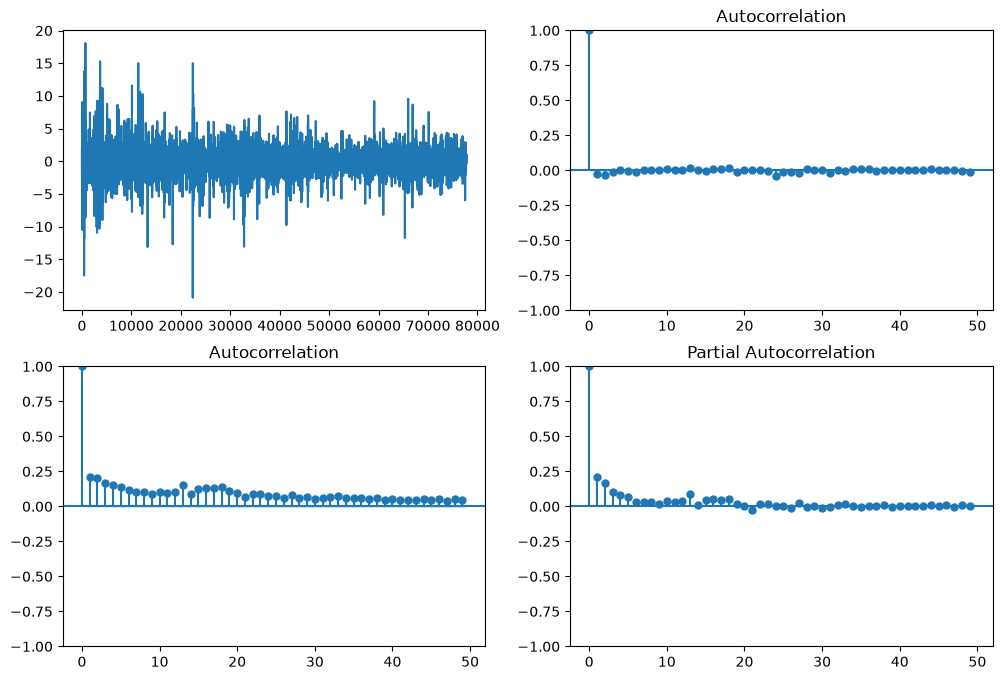

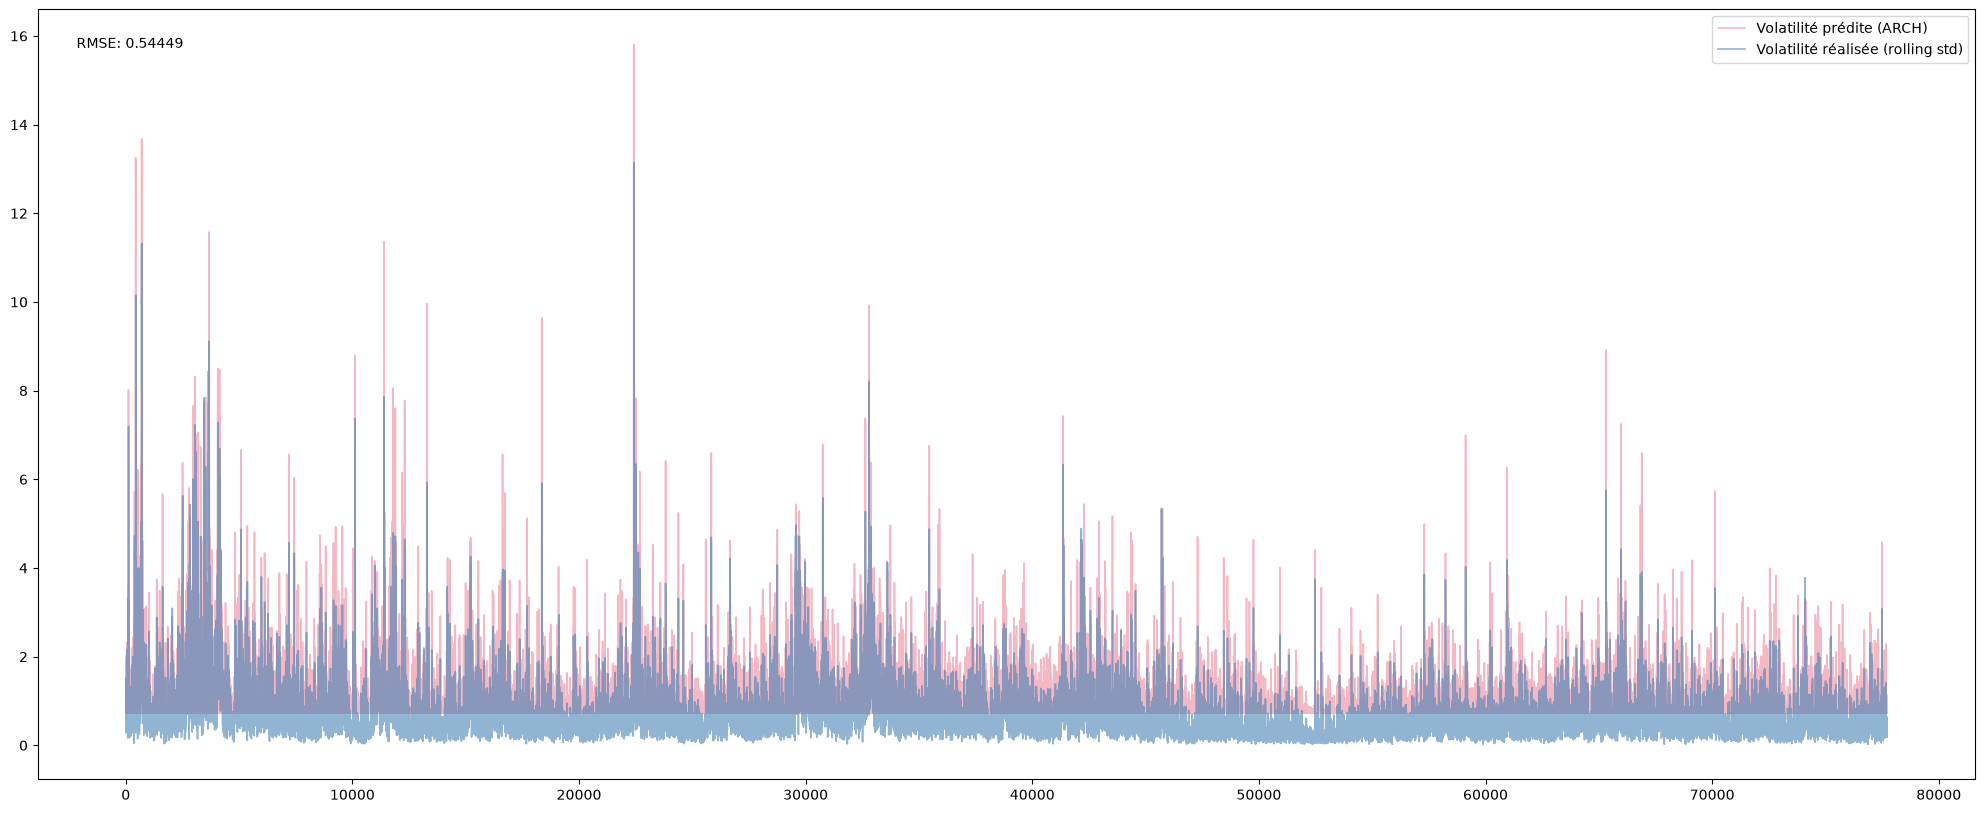

------------------------------------------------------


In [ ]:
for path in glob.glob("data/*.json"):
    regex = re.compile(r"(\w+)(?:(?=\.json))")
    crypto, interval = regex.findall(path)[0].split("_")
    print(f"{crypto} avec l'interval {interval}")
    data = pd.read_json(path)
    modelisation_arch(data=data)
    print("------------------------------------------------------")